# Day 40 — Clustering & K-Means

## 1. What is Clustering?

Clustering is an **unsupervised learning** task: the training data has no target labels, and the algorithm tries to discover groups of similar instances.

There is no single universal definition of a cluster. Different algorithms identify different kinds of structures.

### K-Means intuition

K-Means looks for **k cluster centers (centroids)** and assigns each instance to the closest centroid.

Typical workflow:

1. Choose `k`.
2. Initialize `k` centroids.
3. Assign every instance to its closest centroid.
4. Recompute each centroid as the mean of its assigned instances.
5. Repeat until the assignments/centroids stabilize.

K-Means is especially effective when clusters are reasonably compact and roughly spherical.

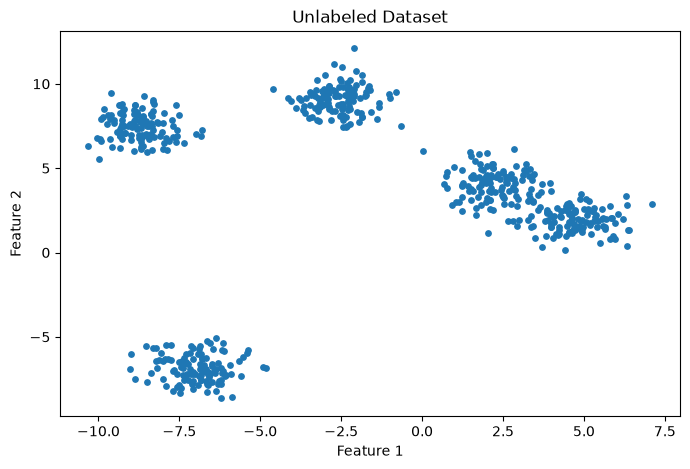

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Reproducible synthetic unlabeled dataset
X, _ = make_blobs(
    n_samples=600,
    centers=5,
    cluster_std=0.8,
    random_state=42
)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=15)
plt.title("Unlabeled Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 2. K-Means with Scikit-Learn

The book demonstrates `KMeans(n_clusters=k)` and `fit_predict()`.

`labels_` contains the cluster index assigned to each training instance, while `cluster_centers_` contains the learned centroids.

In [2]:
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

y_pred = kmeans.fit_predict(X)

print("First 20 cluster labels:")
print(y_pred[:20])

print("\nCluster centers:")
print(kmeans.cluster_centers_)

First 20 cluster labels:
[2 2 0 4 4 1 4 3 0 1 2 0 1 3 3 2 3 4 0 4]

Cluster centers:
[[-8.73495886  7.46358057]
 [ 4.73036406  1.87100982]
 [-6.96440824 -6.86541375]
 [-2.60462291  9.06182016]
 [ 2.24487721  4.10301684]]


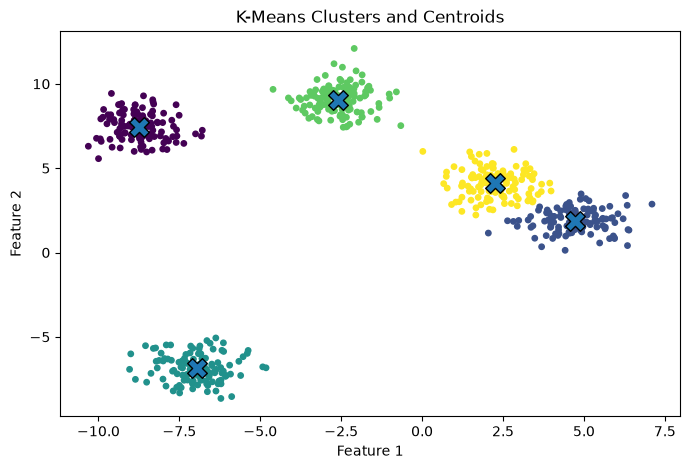

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=15)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolor="black"
)
plt.title("K-Means Clusters and Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 3. Predicting New Instances

Once K-Means is trained, a new instance can be assigned to the cluster whose centroid is closest to it.

In [4]:
X_new = np.array([
    [0, 2],
    [3, 2],
    [-3, 3],
    [-3, 2.5]
])

predicted_clusters = kmeans.predict(X_new)

for point, cluster in zip(X_new, predicted_clusters):
    print(f"Point {point} -> cluster {cluster}")

Point [0. 2.] -> cluster 4
Point [3. 2.] -> cluster 1
Point [-3.  3.] -> cluster 4
Point [-3.   2.5] -> cluster 4


## 4. Inertia

K-Means uses **inertia** to measure how tightly instances are grouped around their closest centroid.

Conceptually:

**Inertia = sum of squared distances from each instance to its assigned centroid.**

Scikit-Learn exposes it as:

```python
kmeans.inertia_
```

Lower inertia means points are, in aggregate, closer to their assigned centroids.

However, inertia **cannot by itself determine the best `k`**, because inertia keeps decreasing as the number of clusters increases.

In [5]:
print("K-Means inertia:", kmeans.inertia_)
print("Negative inertia from score():", kmeans.score(X))

K-Means inertia: 730.4799038468221
Negative inertia from score(): -730.4799038468221


## 5. Initialization and K-Means++

K-Means can converge to a **local optimum**, and the result depends on centroid initialization.

The book discusses:

- Multiple random initializations using `n_init`
- Keeping the solution with the lowest inertia
- **K-Means++**, which chooses initial centroids more intelligently
- Supplying your own initial centroids through `init`

K-Means++ tends to choose centroids that are far apart, reducing the chance of a poor initialization.

In [6]:
# Compare a single initialization with multiple initializations
single_init = KMeans(
    n_clusters=5,
    init="random",
    n_init=1,
    random_state=1
)

multiple_init = KMeans(
    n_clusters=5,
    init="random",
    n_init=20,
    random_state=1
)

single_init.fit(X)
multiple_init.fit(X)

print("Single random initialization inertia:", single_init.inertia_)
print("20 random initializations inertia:", multiple_init.inertia_)

Single random initialization inertia: 1352.1157406943644
20 random initializations inertia: 730.479903846822


### K-Means++ is the default initialization strategy

In modern Scikit-Learn versions, `init="k-means++"` is the default. It is designed to make poor centroid initialization less likely.

In [7]:
kmeans_plus_plus = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,
    random_state=42
)

kmeans_plus_plus.fit(X)

print("K-Means++ inertia:", kmeans_plus_plus.inertia_)

K-Means++ inertia: 730.479903846822


## 6. Choosing the Number of Clusters (`k`) — Elbow Method

Because inertia always tends to decrease as `k` increases, we can plot inertia against `k`.

The curve often has an **elbow**: after a certain point, adding more clusters provides much less improvement.

The elbow is useful, but the book describes this method as relatively coarse.

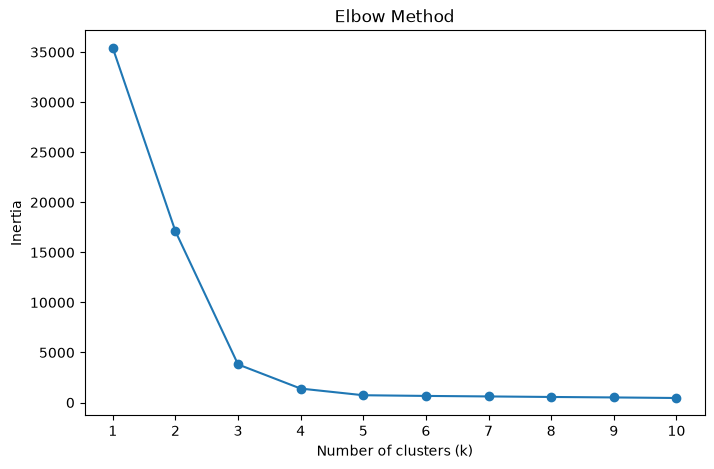

In [8]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.show()

## 7. Silhouette Score

A more informative approach is the **silhouette score**.

For an instance:

- `a` = mean distance to the other instances in its own cluster
- `b` = mean distance to instances in the nearest other cluster
- silhouette coefficient = `(b - a) / max(a, b)`

The coefficient ranges from **-1 to +1**:

- Near **+1** → well inside its cluster and far from other clusters
- Near **0** → near a cluster boundary
- Near **-1** → may have been assigned to the wrong cluster

The overall silhouette score is the mean silhouette coefficient over all instances.

In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)
print("Silhouette score for k=5:", score)

Silhouette score for k=5: 0.7253558707644244


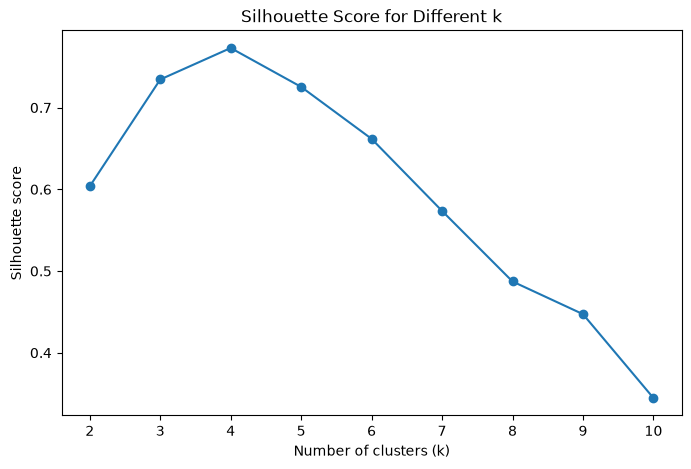

Best silhouette score in this search: 0.7729621150453039
Corresponding k: 4


In [10]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score for Different k")
plt.xticks(range(2, 11))
plt.show()

best_k = list(range(2, 11))[int(np.argmax(silhouette_scores))]
print("Best silhouette score in this search:", max(silhouette_scores))
print("Corresponding k:", best_k)

## 8. Silhouette Diagram

A silhouette diagram shows the silhouette coefficient of every instance, grouped by cluster.

The book uses this visualization to inspect not only the overall score but also:

- cluster size,
- cluster quality,
- whether many points fall below the average silhouette score,
- whether some clusters are poorly separated.

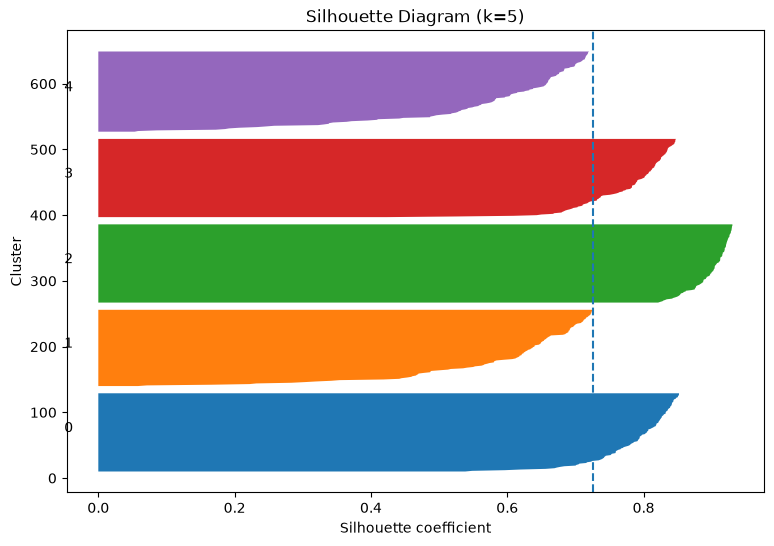

Overall silhouette score: 0.7253558707644244


In [11]:
from sklearn.metrics import silhouette_samples

k = 5
model = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = model.fit_predict(X)

sample_scores = silhouette_samples(X, labels)
overall_score = sample_scores.mean()

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10

for cluster_id in range(k):
    values = sample_scores[labels == cluster_id]
    values.sort()

    size = len(values)
    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        values
    )

    ax.text(-0.05, y_lower + 0.5 * size, str(cluster_id))
    y_lower = y_upper + 10

ax.axvline(overall_score, linestyle="--")
ax.set_title(f"Silhouette Diagram (k={k})")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
plt.show()

print("Overall silhouette score:", overall_score)

## 9. Limits of K-Means

The book highlights several important limitations:

1. You must specify the number of clusters.
2. Multiple runs may be needed to avoid suboptimal solutions.
3. K-Means does not behave well when clusters have:
   - varying sizes,
   - different densities,
   - nonspherical shapes.
4. Feature scaling is important. Without scaling, one feature can dominate distance calculations.
5. A lower inertia does not necessarily mean that the clustering is semantically better.

For elongated/ellipsoidal clusters, other methods such as Gaussian mixture models may be more appropriate.

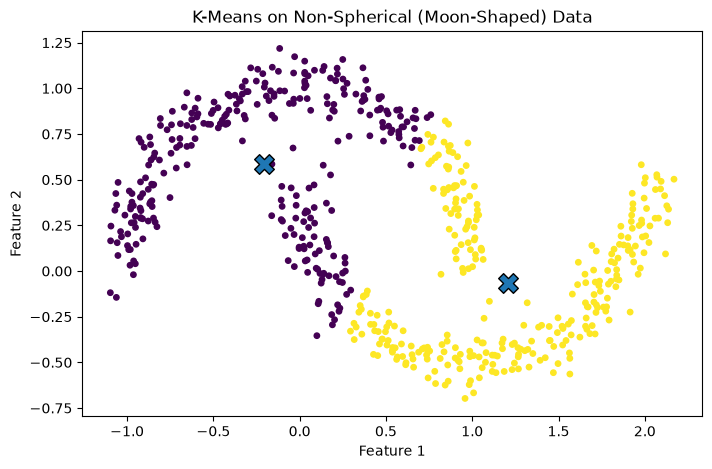

In [12]:
# Demonstrate a case where K-Means struggles with non-spherical clusters
from sklearn.datasets import make_moons

X_moons, _ = make_moons(
    n_samples=600,
    noise=0.08,
    random_state=42
)

moon_kmeans = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=42
)

moon_labels = moon_kmeans.fit_predict(X_moons)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=moon_labels, s=15)
plt.scatter(
    moon_kmeans.cluster_centers_[:, 0],
    moon_kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolor="black"
)
plt.title("K-Means on Non-Spherical (Moon-Shaped) Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 10. Feature Scaling Matters

K-Means relies on distances. If features have very different scales, the larger-scale feature can dominate the distance calculation.

The book therefore recommends scaling input features before K-Means when appropriate.

Here we use `StandardScaler` as a demonstration.

In [13]:
from sklearn.preprocessing import StandardScaler

# Example data with very different feature scales
X_scale = np.column_stack([
    X[:, 0],
    X[:, 1] * 100
])

X_scaled = StandardScaler().fit_transform(X_scale)

scaled_model = KMeans(n_clusters=5, n_init=10, random_state=42)
scaled_labels = scaled_model.fit_predict(X_scaled)

print("Inertia after scaling:", scaled_model.inertia_)

Inertia after scaling: 24.861972583725915


## 11. Image Segmentation with K-Means

The book demonstrates **color segmentation**.

An RGB image can be represented as a 3D array:

`height × width × 3`

where the three channels are red, green, and blue.

We can reshape the image into a long list of RGB vectors, cluster those colors with K-Means, and replace every pixel by the mean color of its cluster.

This reduces the number of distinct colors in the image.

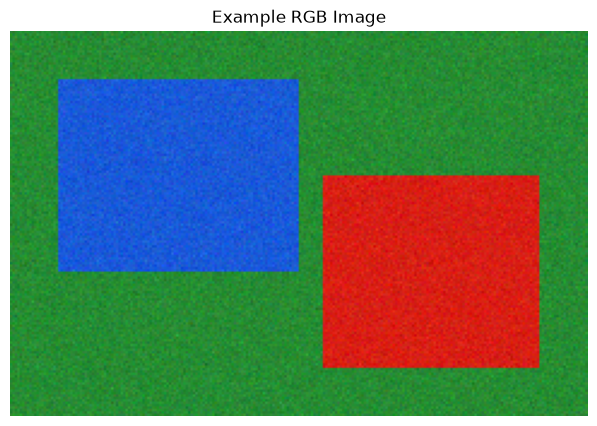

In [14]:
# Create a small synthetic RGB image so the notebook works
# without needing an external image file.

rng = np.random.default_rng(42)

height, width = 160, 240
image = np.zeros((height, width, 3), dtype=float)

# Background
image[:] = [0.15, 0.55, 0.20]

# Large blue region
image[20:100, 20:120] = [0.10, 0.35, 0.85]

# Red object
image[60:140, 130:220] = [0.85, 0.12, 0.08]

# Add mild noise
image += rng.normal(0, 0.035, image.shape)
image = np.clip(image, 0, 1)

plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.title("Example RGB Image")
plt.axis("off")
plt.show()

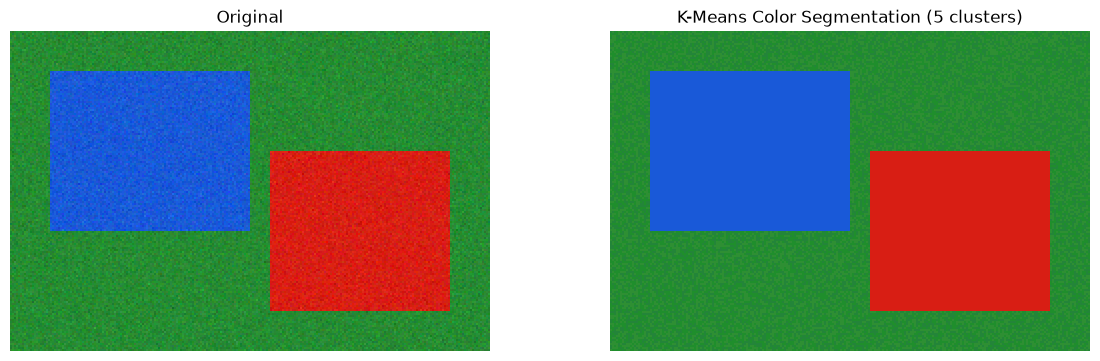

Original number of pixels: 38400
Number of color clusters: 5
Cluster centers (RGB):
[[0.18241658 0.56332795 0.20090568]
 [0.84982906 0.1198607  0.08003622]
 [0.10024005 0.35043615 0.85017299]
 [0.13877543 0.52470481 0.22534223]
 [0.12511909 0.55961786 0.17421337]]


In [15]:
# Reshape pixels into a list of RGB colors
X_image = image.reshape(-1, 3)

n_clusters = 5

image_kmeans = KMeans(
    n_clusters=n_clusters,
    n_init=10,
    random_state=42
)

image_kmeans.fit(X_image)

# Replace every pixel by the mean RGB color of its cluster
segmented = image_kmeans.cluster_centers_[image_kmeans.labels_]
segmented = segmented.reshape(image.shape)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_axes([0.05, 0.15, 0.4, 0.75])
ax1.imshow(image)
ax1.set_title("Original")
ax1.axis("off")

ax2 = fig.add_axes([0.55, 0.15, 0.4, 0.75])
ax2.imshow(segmented)
ax2.set_title(f"K-Means Color Segmentation ({n_clusters} clusters)")
ax2.axis("off")

plt.show()

print("Original number of pixels:", X_image.shape[0])
print("Number of color clusters:", n_clusters)
print("Cluster centers (RGB):")
print(image_kmeans.cluster_centers_)

### Image segmentation takeaway

K-Means can group pixels with similar colors and replace their colors with cluster-center colors.

The book points out an important limitation: because K-Means tends to favor clusters of similar sizes, a small but visually distinctive object may fail to receive its own cluster when too few color clusters are used.

### Summary

**K-Means**
- Unsupervised clustering algorithm.
- Requires a chosen `k`.
- Learns cluster centroids.
- Assigns each observation to its nearest centroid.
- Recomputes centroids repeatedly.

**Inertia**
- Measures within-cluster squared distances.
- Lower is better for a fixed `k`.
- Cannot be used alone to choose `k`.

**Initialization**
- Poor initialization can lead to a local optimum.
- K-Means++ improves initialization.
- Multiple initializations can reduce this risk.

**Choosing k**
- Elbow method → inspect diminishing improvement in inertia.
- Silhouette score → evaluate cohesion and separation.

**Limitations**
- Sensitive to scaling.
- Needs `k`.
- Can struggle with different sizes/densities and nonspherical clusters.

**Image segmentation**
- Treat RGB pixel values as observations.
- Cluster similar colors.
- Replace each pixel with its cluster-center color.